# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

<div>
    
|    Group   |           1          |
|------------|----------------------|
| Junhan Chong  |        6153283       |
| Jack Bergmann  |        6200850       |
| Madhav Tiwari  |        6141870       |
| Ben Chen  |        6543405       |

#### Imports

In [2]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [3]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        # find all possible actions for the particular state that the agent is in
        valid_as = agent.get_valid_actions(maze)
        # choose an action from the list of valid actions randomly, with uniform distribution
        chosen_action = np.random.choice(valid_as)
        # take the chosen action
        return chosen_action

        


    def e_greedy(self, agent: Agent, maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        # find all possible actions for the particular state that the agent is in
        valid_as = agent.get_valid_actions(maze)
        s = agent.get_state(maze)

        # find the corresponding q values for the possible actions
        q_vals = [self.q_table.get_q(s, a) for a in valid_as]

        # find the actions with largest q value(s)
        max_q = np.max(q_vals)
        max_q_actions = [a for a, q in zip(valid_as, q_vals) if q == max_q]

        chosen_action = None
        # with probability of 1 - eps, select randomly from actions with the largest q values
        if (np.random.uniform() > eps):
            chosen_action = np.random.choice(max_q_actions)
        # with probability of eps, select randomly from the list of possible actions
        else:
            not_max = [a for a in valid_as if a not in max_q_actions]
            if len(not_max) == 0:
                chosen_action = np.random.choice(valid_as)
            else:
                chosen_action = np.random.choice(not_max)
        # take the chosen action
        return chosen_action



    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """
        # find all possible actions for the particular state that the agent is in
        valid_as = agent.get_valid_actions(maze)
        s = agent.get_state(maze)

        # find the corresponding q values for the possible actions
        q_vals = [self.q_table.get_q(s, a) for a in valid_as]
        # subtract max q val for numerical stability
        q_vals = np.array(q_vals)
        q_vals = q_vals - np.max(q_vals)

        # guard against zero-division
        if temperature <= 0:
            # apply greedy if temperature is zero
            max_q = np.max(q_vals)
            max_q_actions = [a for a, q in zip(valid_as, q_vals) if q == max_q]
            chosen_action = np.random.choice(max_q_actions)
            return chosen_action

        # calculate exp(Q(s,a) / T) for all possible actions
        boltzmann_probs = np.exp(q_vals / temperature)

        # find the sum and divide each term by the sum
        boltzmann_probs /= np.sum(boltzmann_probs)

        
        # choose an action with the boltzmann probabilities as the weights
        chosen_action = np.random.choice(valid_as, p=boltzmann_probs)

        # take the chosen action
        return chosen_action

<div>

**Explain what you did, including the initial selection of the hyper-parameter values. How do you deal with exploration/exploitation tradeoff?**

All three strategies start with finding the valid actions that the agent can take at its current state/position in the maze. This is because an at any point, an agent may be directly next to walls, in which case the probability of choosing an invalid action (moving into the wall) should be zero in all given strategies.

For random exploration, we chose an action randomly based on the uniform distribution between the available actions. Therefore, there are no hyper-parameters for this strategy. This exploration strategy can be used initially to maximise exploration for the agent to learn about the environment.

For $\epsilon$-greedy exploration, we find the corresponding Q values for the possible (state, action) pairs for the agent's given state for the greedy property of this strategy. We can simply choose the action with the highest associated Q value to add exploitation. However, this approach would neglect exploration since the agent deterministically chooses what action to take. Therefore, we use a hyperparameter: $\epsilon$, to re-introduce exploration. As $\epsilon$ represents the probability of a random action being chosen, increasing it will naturally discourage exploitation and encourage exploration. Therefore, we must find a suitable value of $\epsilon$ to achieve a good balance of exploitation and exploration to avoid convergence at a local optima, while keeping the learning relatively fast and efficient.

For Boltzmann exploration, we use the Q values for all possible state action pairs (like the first step of the $\epsilon$-greedy strategy) as weights for a probabilistic approach. With the Q-values, apply softmax formula to assign probabilities for the possible actions. However, solely using the softmax function to assign probabilities means that we cannot tune the strategy to encourage or discourage more exploitation. Therefore, we introduce a hyperparameter $\tau$ (true Boltzmann exploration) which influences the probability of all possible actions. As we increase $\tau$, the probabilities decrease exponentially to its magnitude (because of the exponentiation). Hence, decreasing $\tau$ leads to more exploitation (as the higher Q value actions would be assigned a larger the probability relative to the lower Q value actions) while increasing it will even out the probability distribution towards uniform distribution; As $\tau$ approaches the limit of 0, the approach becomes greedier and greedier, while $T$ approaching infinity would make the strategy choose actions from a uniform distribution.

In practice, we should choose hyperparameters that encourage exploration (large $\epsilon$, large $\tau$) initially, so the agent can learn about the environment and map out a sensible Q table. As the agent explores, we can incrementally decrease the hyperparameters to favour more exploitation.

Hence, we can use Boltzmann exploration with a large value of $\tau$ initially to encourage exploration, then gradually 'decay' the temperature over each episode until it reaches a threshold to increase exploitation gradually. Since we have four actions per state, with a reward of 10 at the terminal state (initially), our Q values will not be larger than 10. Therefore, we can choose a relatively small value for the temperature, such as $\tau = 1$. Then we can use a fixed percentage value such as 0.99 to slowly decay the temperature over episodes. These hyper-parameters can be optimised during training (with the validation set) to maximise efficiency while minimising the risk of early convergence at a local optima.

#### Question 2

In [4]:
# Create a Maze instance.
easy_maze = Maze("./../data/easy_maze.txt")
easy_maze.set_reward(x = 9, y = 9, reward = 10)
easy_maze.set_terminal(x = 9, y = 9)

def main_no_learn(maze, n_episodes = 300, alpha = 0.1, discount = 0.9, decay = 0.99, temperature = 1):
    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []

    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": 0.7, "gamma": 0.9}
    # learner = QLearning(q_table, params)

    
    # repeat exploration #n_episodes amount of time
    for _ in tqdm(range(n_episodes)):
        # put agent at the start
        agent.reset()

        #counter to check progress
        steps = 0
        total_r = 0

        done = agent.get_state(maze).done

        # explore until terminal state
        while (done == False):
            # one exploration step
            current_state = agent.get_state(maze)
            chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            next_state, r, done = agent.step(chosen_action, maze)

            ## updating Q table is the learner's job ##
            ## NOT IMPLEMENTED AS STATED IN QUESTION 2 ##
            
            # re-assign/increment control variables
            current_state = next_state
            total_r += r
            steps += 1
        
        # decay the temperature every episode
        temperature *= decay

        # append progress variables to progress tracker
        episode_rewards.append(total_r)
        episode_lengths.append(steps)


<div>

**Explain the cycle in your report.**

The cycle consists of three steps until the agent reaches a terminal state:
1. **Take action step:** We decide on the action for the agent to take. We used the Boltzmann strategy, with an initial temperature of 1.0. We then take the chosen action, getting the new state and reward for the action (at the particular state) as a return value. <br>
*\<This step is necessary for the agent to explore the environment\>*
2. **Update Q table:** We take the Q values of the initial state and action that we've chosen, as well as the Q values for max state-action value for the next state. Using these, we calculate the new Q value for the initial state-action pair. <br>
*\<This step is necessary to learn the environment. Q table is what is used to exploit efficient paths\>*
3. **Update states and reward metrics:** We then update the current state variable to the new position of the agent, as well as incrementing the rewards and step count to use as a performance metric. <br>
*\<This step is necessary to evaluate progress and allow for a cycle\>*

This cycle can be repeated until the agent reaches the terminal state, at which a new episode will start. These three steps are sufficient for a complete trial/episode (agent exploring from the start to terminal state) as it can explore the environment and learn from it (Q table). Repeating this cycle over the episodes will lead to a convergence in the Q value according to the **Stochastic Approximation Theory**. Then we can improve the policy based on the values from the Q table.

#### Question 3

In [5]:
def main_early_stop_no_learn(maze, n_episodes = 300, decay = 0.99, temperature = 1, early_stop = 30000):
    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []

    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)

    # Create a QTable
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    
    # Create an ExplorationStrategy
    exploration_strategy = ExplorationStrategy(q_table)

    # global step tracker
    total_steps = 0
    episodes = 0

    # repeat exploration #n_episodes amount of time
    for _ in range(n_episodes):
        # put agent at the start
        agent.reset()

        #counter to check progress
        steps = 0
        total_r = 0

        done = agent.get_state(maze).done

        # explore until terminal state
        while (done == False):
            if (total_steps >= early_stop):
                break
            ## STEP 1: TAKE STEP ##
            current_state = agent.get_state(maze)
            chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            next_state, r, done = agent.step(chosen_action, maze)

            ## STEP 2: UPDATE Q TABLE / LEARN ##
            
            ## STEP 3: RECORD STATE AND REWARDS ##
            # re-assign/increment control variables
            current_state = next_state
            total_r += r
            steps += 1
            total_steps += 1
        
        # decay the temperature every episode
        temperature *= decay

        # append progress variables to progress tracker
        episode_rewards.append(total_r)
        episode_lengths.append(steps)

        episodes += 1
        print(f"{ steps } steps at episode { episodes }")

        if (total_steps >= early_stop):
            print(f"{ total_steps } steps reached. Terminating current episode.")
            print(f"Stopped at episode number: { episodes }")
            break
        
    return episode_lengths

In [6]:
main_early_stop_no_learn(easy_maze)

478 steps at episode 1
234 steps at episode 2
3294 steps at episode 3
348 steps at episode 4
248 steps at episode 5
378 steps at episode 6
7350 steps at episode 7
426 steps at episode 8
1856 steps at episode 9
10784 steps at episode 10
4604 steps at episode 11
30000 steps reached. Terminating current episode.
Stopped at episode number: 11


[478, 234, 3294, 348, 248, 378, 7350, 426, 1856, 10784, 4604]

<div>

We introduce a global step counter that gets incremented at every step. Since there are two loops (the outer loop iterating over the episodes and the inner loop iterating over the cycles), we include a break statement in both blocks to ensure that the cycle and the episode both terminate once the step counter reaches 30,000. To verify, we included two simple print statements printing some meta data about the runs (number of episodes, and total steps).

We can also note from the steps per episode, that there is a very large variance between episodes, ranging from 100 to over 10,000 steps per episode. There also doesn't seem to be a clear decrease in the number of steps per episode. This is expected as we have not implemented the learning function.

#### Question 4

In [ ]:
toy_maze = Maze("./../data/toy_maze.txt")
toy_maze.set_reward(x = 9, y = 9, reward = 10)
toy_maze.set_terminal(x = 9, y = 9)

def run_multiple_no_learn(maze, n_runs = 10, early_stop = 30000):
    all_runs = []

    # get the episode lengths from n_runs number of tries
    for _ in range(n_runs):
        episode_lengths = main_early_stop_no_learn(
            maze, early_stop
        )
        all_runs.append(episode_lengths)

    return all_runs


def plot_average_episode_lengths(all_runs, difficulty, learning_type = "None"):
    # find max number of episodes across runs
    max_len = max(len(run) for run in all_runs)

    # pad runs with NaN so they all have equal length
    padded_runs = []
    for run in all_runs:
        padded = run + [np.nan] * (max_len - len(run))
        padded_runs.append(padded)

    padded_runs = np.array(padded_runs)

    # compute mean and std ignoring NaNs
    avg_lengths = np.nanmean(padded_runs, axis=0)
    stds = np.nanstd(padded_runs, axis=0)
    epochs = np.arange(len(avg_lengths)) # for axis labelling clarity

    plt.figure()
    # plotting averages
    plt.plot(epochs, avg_lengths, label="Average")
    # plotting standard deviation region
    plt.fill_between(
        epochs,
        np.maximum(avg_lengths - stds, 0),
        avg_lengths + stds,
        alpha=0.3
    )
    plt.xlim(0, 150)
    plt.xlabel("Episode")
    plt.ylabel("Average Steps per Episode")
    if learning_type == "None":
        plt.title(f"Average episode length over runs in { difficulty } maze")
    else:
        plt.title(f"Average episode length over runs in { difficulty } maze using {learning_type}")
    plt.show()




4288 steps at episode 1
988 steps at episode 2
622 steps at episode 3
2468 steps at episode 4
2444 steps at episode 5
646 steps at episode 6
2662 steps at episode 7
1068 steps at episode 8
2170 steps at episode 9
2322 steps at episode 10
1290 steps at episode 11
678 steps at episode 12
618 steps at episode 13
170 steps at episode 14
1416 steps at episode 15
3256 steps at episode 16
1792 steps at episode 17
1102 steps at episode 18
30000 steps reached. Terminating current episode.
Stopped at episode number: 18
524 steps at episode 1
2428 steps at episode 2
2104 steps at episode 3
2082 steps at episode 4
820 steps at episode 5
2484 steps at episode 6
1108 steps at episode 7
702 steps at episode 8
1810 steps at episode 9
800 steps at episode 10
276 steps at episode 11
5346 steps at episode 12
1226 steps at episode 13
774 steps at episode 14
648 steps at episode 15
452 steps at episode 16
864 steps at episode 17
386 steps at episode 18
1300 steps at episode 19
448 steps at episode 20
436 s

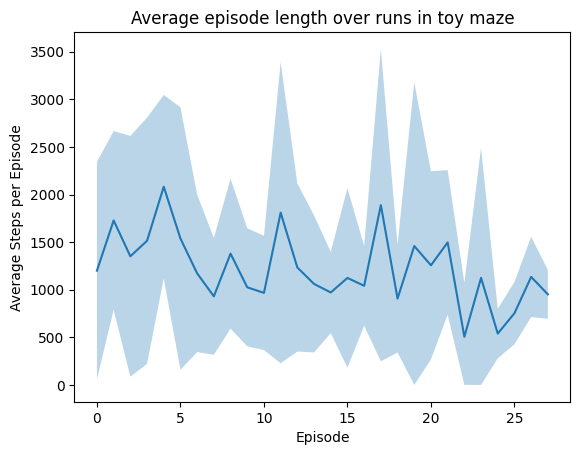

512 steps at episode 1
2180 steps at episode 2
2514 steps at episode 3
1822 steps at episode 4
1996 steps at episode 5
656 steps at episode 6
374 steps at episode 7
126 steps at episode 8
2712 steps at episode 9
5164 steps at episode 10
5934 steps at episode 11
6010 steps at episode 12
30000 steps reached. Terminating current episode.
Stopped at episode number: 12
1114 steps at episode 1
270 steps at episode 2
3314 steps at episode 3
188 steps at episode 4
1562 steps at episode 5
3626 steps at episode 6
906 steps at episode 7
122 steps at episode 8
12200 steps at episode 9
6698 steps at episode 10
30000 steps reached. Terminating current episode.
Stopped at episode number: 10
13552 steps at episode 1
3480 steps at episode 2
4782 steps at episode 3
594 steps at episode 4
5938 steps at episode 5
230 steps at episode 6
1424 steps at episode 7
30000 steps reached. Terminating current episode.
Stopped at episode number: 7
7400 steps at episode 1
2412 steps at episode 2
3292 steps at episode

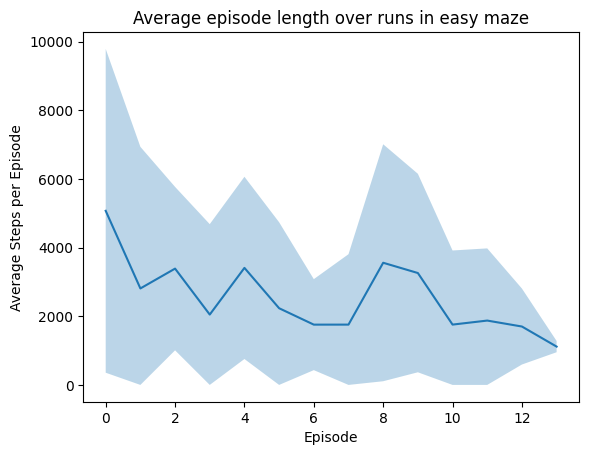

In [8]:
plot_average_episode_lengths(run_multiple_no_learn(toy_maze, early_stop=100000), "toy")
plot_average_episode_lengths(run_multiple_no_learn(easy_maze, early_stop=300000), "easy")

<div>

The plot shows that there is no clear downwards trend for each consecutive episodes in the average over all runs. This indicates that the agent does not take more efficient paths over each episodes due to the lack of learning (updating of the Q table).
Towards the end of the runs, the average is calculated from less values than earlier because some runs might terminate earlier. Therefore, there may be an increased volatility that makes it look like the plot is showing certain trends. This is shown through the smaller standard deviation towards the later episodes.

#### Question 5

In [ ]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        # if agent already at destination, exit
        if (done): return
        # variables for Q table update calculations
        q_old = self.q_table.get_q(state, action)
        q_max_new = np.max([self.q_table.get_q(next_state, a) for a in possible_actions])

        # update Q table
        self.q_table.set_q(state, action, 
                    q_old + self.params["lr"] * (reward + self.params["gamma"] * q_max_new - q_old))

In [ ]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        # if agent already at destination, exit
        if (done): return
        # variables for Q table update calculations
        q_old = self.q_table.get_q(state, action)
        q_new = self.q_table.get_q(next_state, next_action)

        # update Q table
        self.q_table.set_q(state, action, 
                    q_old + self.params["lr"] * (reward + self.params["gamma"] * q_new - q_old))

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

#### Question 6

In [67]:
def main_early_stop(maze, n_episodes = 300, learner_params = {"lr": 0.7, "gamma": 0.9}, decay = 0.99, eps = 0.1, temperature = 1, early_stop = 30000, q_learning=True, strategy="boltzmann", decay_enabled = True):
    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []

    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)

    # Create a QTable
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    
    # Create an ExplorationStrategy
    exploration_strategy = ExplorationStrategy(q_table)

    # Create a learner
    if (q_learning):
        learner = QLearning(q_table, learner_params)
    else:
        learner = SARSA(q_table, learner_params)

    # global step tracker
    total_steps = 0
    episodes = 0

    # repeat exploration #n_episodes amount of time
    for _ in range(n_episodes):
        # put agent at the start
        agent.reset()

        #counter to check progress
        steps = 0
        total_r = 0

        done = agent.get_state(maze).done

        # explore until terminal state
        while (done == False):
            if (total_steps >= early_stop):
                break
            # one exploration step
            current_state = agent.get_state(maze)
            if strategy == "random":
                chosen_action = exploration_strategy.random(agent, maze)
            elif strategy == "e_greedy":
                chosen_action = exploration_strategy.e_greedy(agent, maze, eps)
            else:
                chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)

            next_state, r, done = agent.step(chosen_action, maze)
                
            # variables for Q table update calculations
            if (q_learning):
                learner.learn(agent.get_valid_actions(maze), current_state, chosen_action, next_state, r, done)
            else:
                next_action = exploration_strategy.boltzmann(agent, maze, temperature)
                learner.learn(current_state, chosen_action, next_state, next_action, r, done)

            # re-assign/increment control variables
            current_state = next_state
            total_r += r
            steps += 1
            total_steps += 1
        
        # decay the temperature every episode
        if (decay_enabled):
            temperature *= decay

        # append progress variables to progress tracker
        episode_rewards.append(total_r)
        episode_lengths.append(steps)

        episodes += 1
        # print(f"{ steps } steps at episode { episodes }")

        if (total_steps >= early_stop):
            # print(f"{ total_steps } steps reached. Terminating current episode.")
            # print(f"Stopped at episode number: { episodes }")
            break
        
    return episode_lengths



In [69]:
def run_multiple_q(maze, n_runs = 10, n_episodes = 300, learner_params = {"lr": 0.7, "gamma": 0.9}, decay = 0.99, eps = 0.1, temperature = 1, early_stop = 30000, q_learning=True, strategy="boltzmann", decay_enabled = True):
    all_runs = []

    for _ in range(n_runs):
        episode_lengths = main_early_stop(maze, n_episodes=n_episodes, learner_params=learner_params, decay=decay, eps=eps, temperature=temperature, early_stop=early_stop, q_learning=q_learning, strategy=strategy, decay_enabled=decay_enabled)
        all_runs.append(episode_lengths)

    return all_runs

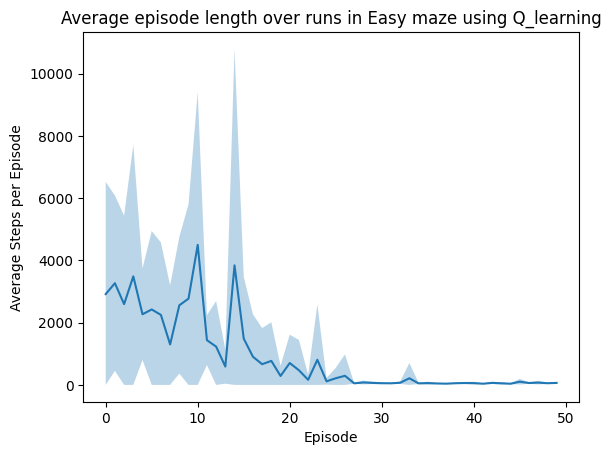

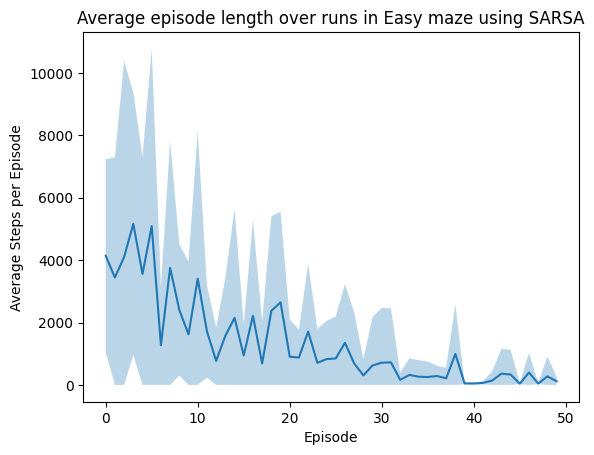

In [72]:
plot_average_episode_lengths(run_multiple_q(easy_maze, n_episodes = 50, early_stop=100000), "Easy", learning_type="Q_learning")
plot_average_episode_lengths(run_multiple_q(easy_maze, n_episodes = 50, early_stop=100000, q_learning = False), "Easy", learning_type="SARSA")

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 7

<div style="background-color:#f1be3e">

_Write your answer here._

### 2.2 Optimization
#### Question 8

In [74]:
# Used for plotting comparisons of different hyperparameters
def plot_comparison(all_data_dict, title):
    plt.figure()
    for label, all_runs in all_data_dict.items():
        max_len = max(len(run) for run in all_runs)
        padded_runs = [run + [np.nan] * (max_len - len(run)) for run in all_runs]
        padded_runs = np.array(padded_runs)
        avg_lengths = np.nanmean(padded_runs, axis=0)
        epochs = np.arange(len(avg_lengths))

        plt.plot(epochs, avg_lengths, label=label)

    plt.xlabel("Episode")
    plt.ylabel("Average Steps per Episode")
    plt.title(title)
    # limit the range of the graph to ensure visibility
    plt.legend()
    plt.show()


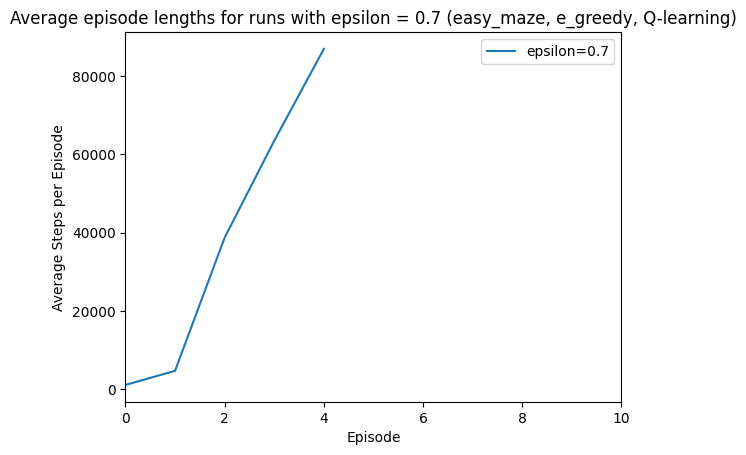

In [ ]:
# separate graph for epsilon = 0.7 to show divergence
episilon_data = {}

episilon_data[f"epsilon=0.7"] = run_multiple_q(easy_maze, early_stop=100000, strategy="e_greedy", eps=0.7)
plot_comparison(episilon_data, "Average episode lengths for runs with epsilon = 0.7 (easy_maze, e_greedy, Q-learning)", max_episodes=10)

epsilon: 0.5 episilon finished
epsilon: 0.3 episilon finished
epsilon: 0.1 episilon finished
epsilon: 0 episilon finished


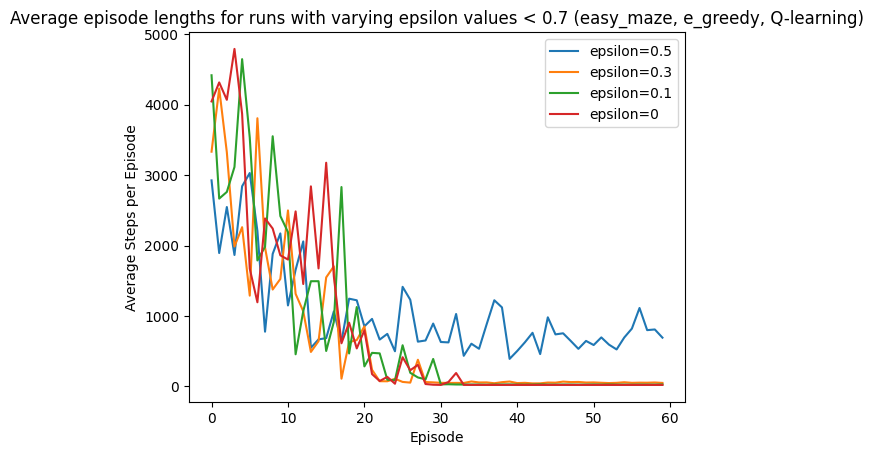

In [ ]:
# plotting lower epsilon values that converges
episilon_data = {}

for eps in [0.5, 0.3, 0.1, 0]:
    episilon_data[f"epsilon={ eps }"] = run_multiple_q(easy_maze, n_episodes=60, early_stop=100000, strategy="e_greedy", eps=eps)
    print(f"epsilon: { eps } episilon finished")

plot_comparison(episilon_data, "Average episode lengths for runs with varying epsilon values < 0.7 (easy_maze, e_greedy, Q-learning)")

<div>

As shown in the plot, $\epsilon$=0.7 fails to converge within the given episodes, as the high exploration rate prevents the agent from effectively exploiting the learned Q-table. In fact, the average steps increase over episodes as the agent chooses randomly except the highest Q value action with a probability of 0.7.

The remaining four values ($\epsilon$=0, 0.1, 0.3, 0.5) converge at a comparable rate in the early episodes. However, their long-term performance differs noticeably:

$\epsilon$=0, 0.1, and 0.3 all converge to a very low and stable number of steps, with $\epsilon$=0 achieving the lowest. $\epsilon$=0.5 shows signs of faster convergence in the first 10 episodes compared to the other values, likely because its higher exploration rate allows the agent to stumble upon a more optimal path earlier. Similarly, $\epsilon$=0.3 also shows slightly faster initial convergence than $\epsilon$=0 and 0.1. However, both $\epsilon$=0.3 and $\epsilon$=0.5 ultimately converge to a higher number of steps, as their exploration rates remain too high for this environment to allow full exploitation.

Overall, lower $\epsilon$ values lead to better final performance in this environment. Since the easy maze is not complex enough to require extensive exploration to avoid local optima, even a small amount of exploration is sufficient to find the optimal path.

#### Question 9

<div>

Lower $\epsilon$ values favour exploitation, meaning the agent is more likely to choose the action with the greatest estimated Q-value. This enables the agent to converge more quickly and find a better path. However, given that it rarely considers other options that may result in higher long-term returns, the agent runs the risk of being trapped in a local optimum.

A high $\epsilon$ favours exploration, and the agent takes random actions more frequently. This lowers the risk of converging to a local optimum, as the agent is more likely to discover potentially better paths. However, excessive exploration slows down convergence and may prevent the agent from effectively exploiting its learned knowledge, leading to a higher average number of steps per episode even after many episodes.

The key challenge is finding a balance point where the agent explores enough to avoid local optima, while still being able to exploit its knowledge to converge to a low step count. The optimal value of $\epsilon$ depends on the complexity of the environment. In simple environments like the easy maze, a low $\epsilon$ is sufficient. In more complex environments, a higher $\epsilon$ may be necessary to avoid getting stuck in a local optimum.

#### Question 10

20 finished
5 finished
1 finished
0.1 finished
0 finished


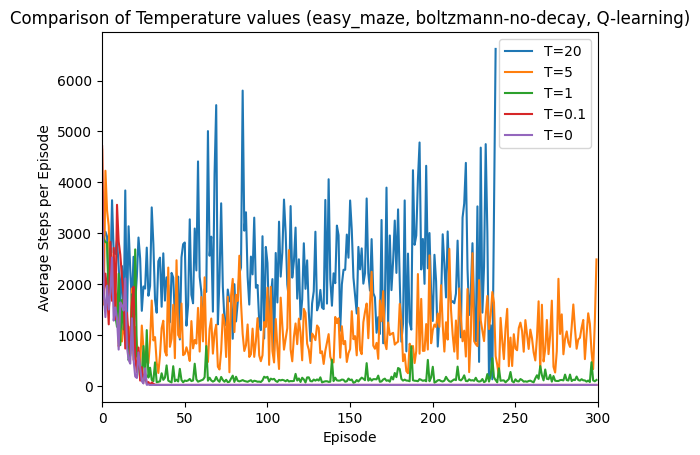

In [ ]:
temperature_data = {}

for t in [20, 5, 1, 0.1, 0]:
    temperature_data[f"T={t}"] = run_multiple_q(easy_maze, early_stop=500000, strategy="boltzmann", temperature=t, decay_enabled = False)
    print(f"{t} finished")

plot_comparison(temperature_data, "Comparison of Temperature values (easy_maze, boltzmann-no-decay, Q-learning)", max_episodes=300)

<div>
As shown in the plot, without decay, higher T values (T = 20, T = 5) fail to converge entirely, fluctuating at high step counts throughout the rest of episodes, while T = 1 converge rapidly in the early episodes, but fails to converge into a consistently low and stable count. 
Lower T values (T = 0, T = 0.1) converge relatively quickly, as they are exploitative from the start. 

This illustrate the importance of temperature decay in Boltzmann exploration, particularly when a higher initial temperature is used.

20 finished
5 finished
1 finished
0.1 finished
0 finished


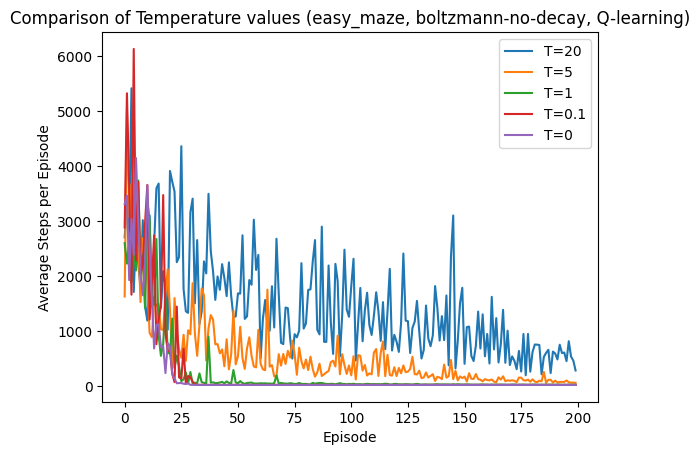

In [ ]:
temperature_no_decay_data = {}
for t in [20, 5, 1, 0.1, 0]:
    temperature_no_decay_data[f"T={t}"] = run_multiple_q(easy_maze, n_episodes=200, early_stop=500000, strategy="boltzmann", temperature=t, decay_enabled = True)
    print(f"{t} finished")

plot_comparison(temperature_no_decay_data, "Comparison of Temperature values (easy_maze, boltzmann-no-decay, Q-learning)")

<div>

Compared to the plot without decay, this plot shows that higher T values (T=20, T=5) result in eventual convergence, With the temperature decay gradually shifting the agent towards exploitation over time, T=20 and T=5 leads to convergence, even though they still fail to outperform lower T values.

Lower T values (T=0, T=0.1, T=1) with decay show similar behaviour as without decay and reach very low average steps per episode. T=0 achieves the lowest step count again in this environment with temperature decay.

The trade-off for Boltzmann exploration lies in balancing computational cost against the complexity of the environment. In a simple environment like the easy maze, a low T value is sufficient, as the agent needs very little exploration to find the optimal path. In more complex environments, a higher T value may be necessary to avoid local optima, but this comes at the cost of significantly more computational resources and episodes before convergence. Therefore, the optimal T must be chosen based on the complexity of the environment and the available computational budget.

#### Question 11

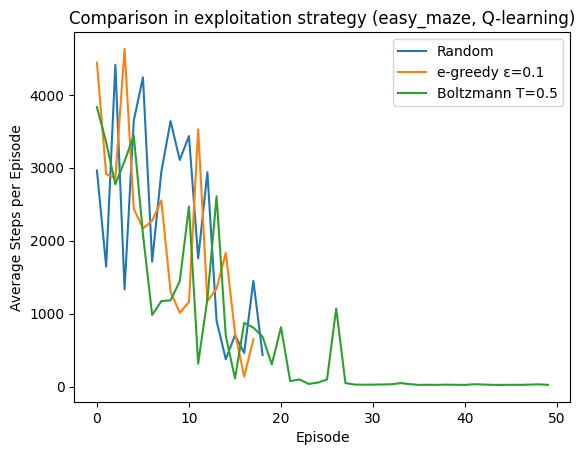

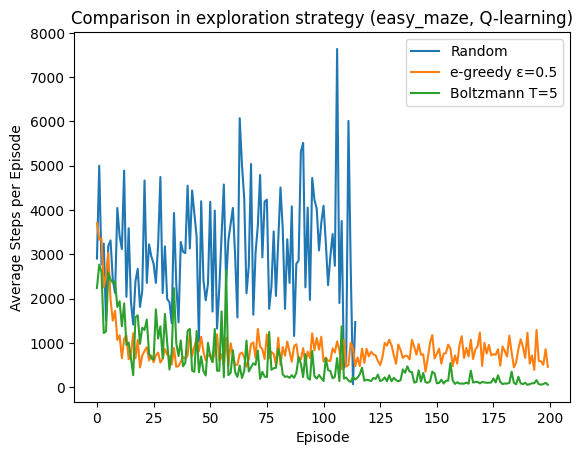

In [ ]:
data_low_value = {
    "Random": run_multiple_q(easy_maze, n_episodes=50, strategy="random"),
    "e-greedy ε=0.1": run_multiple_q(easy_maze, n_episodes=50, strategy="e_greedy", eps=0.1),
    "Boltzmann T=0.5": run_multiple_q(easy_maze, n_episodes=50, strategy="boltzmann", temperature=0.5),
}

data_high_value = {
    "Random": run_multiple_q(easy_maze, n_episodes=200, early_stop=300000, strategy="random", n_runs=10),
    "e-greedy ε=0.5": run_multiple_q(easy_maze, n_episodes=200, early_stop=300000, strategy="e_greedy", eps=0.5),
    "Boltzmann T=5": run_multiple_q(easy_maze, n_episodes=200, early_stop=300000, strategy="boltzmann", temperature=5),
}

plot_comparison(data_low_value, "Comparison in exploitation strategy (easy_maze, Q-learning)")
plot_comparison(data_high_value, "Comparison in exploration strategy (easy_maze, Q-learning)")

<div>

Two comparisons are shown: 
- low exploration settings ($\epsilon$-greedy $\epsilon$=0.1, Boltzmann T=0.5)
- high exploration settings ($\epsilon$-greedy $\epsilon$=0.5, Boltzmann T=5).

In both plots, they are compared against random exploration.

In the low exploration setting, all three strategies perform similarly, with e-greedy and Boltzmann both converging quickly to a low step count. The random strategy converges the slowest, as it makes no use of the learned Q-values at any point.

In the high exploration setting, a clear difference emerges between $\epsilon$-greedy and Boltzmann. $\epsilon$-greedy converges quickly initially but stabilises at a relatively high step count, as its fixed exploration rate prevents it from fully exploiting its learned knowledge. Boltzmann, on the other hand, converges more slowly but continues to improve over time, eventually reaching a much lower step count. This is because Boltzmann has temperature decay, which gradually reduces the exploration rate over episodes, allowing the agent to shift from broad exploration to focused exploitation. $\epsilon$-greedy has no equivalent mechanism, so a high ε permanently limits its final performance.

The random strategy fails to converge meaningfully in either setting, as it never uses the Q-table for action selection.

Overall, when computational resources are limited and only local optima are required, all three strategies perform comparably. When more thorough exploration is needed to find a globally optimal path, Boltzmann outperforms $\epsilon$-greedy due to its temperature decay mechanism.

#### Question 12

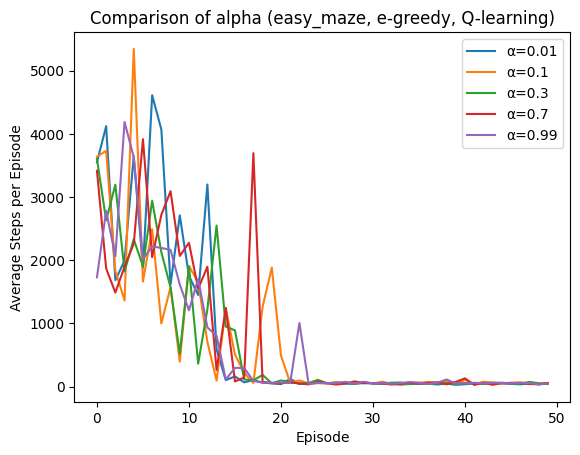

In [ ]:
all_data = {}

for a in [0.01, 0.1, 0.3, 0.7, 0.99]:
    all_data[f"α={a}"] = run_multiple_q(easy_maze, n_episodes=50, early_stop=30000, strategy="e_greedy", eps=0.3, learner_params={"lr": a, "gamma": 0.9})

plot_comparison(all_data, "Comparison of alpha (easy_maze, e-greedy, Q-learning)")

<div>

As shown in the plot, the five values of $\alpha$ (0.01, 0.1, 0.3, 0.7, 0.99) show very similar convergence behaviour, with all values reaching a low and stable step count within approximately the same number of episodes. This suggests that in the easy maze, the learning rate does not have a significant impact on either convergence speed or final performance.

Theoretically, a higher $\alpha$ means each Q-value update has a larger magnitude, allowing information to propagate faster through the Q-table and leading to faster convergence. A lower $\alpha$ updates more conservatively and requires more episodes to converge, but may produce a more stable Q-table. The occasional spikes visible in the plot are consistent with this, as larger updates can cause temporary instability in the Q-values.

The lack of clear difference between α values is likely due to the simplicity of the easy maze. The environment is straightforward enough that all tested learning rates can find the optimal path within the given number of episodes. In a more complex environment with a larger state space, the effect of α on convergence speed would be more pronounced.

### 2.3 Introducing More Rewards
#### Question 13

In [ ]:
toy_maze = Maze("./../data/easy_maze.txt")
toy_maze.set_reward(x=9, y=9, reward=10)
toy_maze.set_terminal(x=9, y=9)

# new non-terminal state with reward
toy_maze.set_reward(x=9, y=0, reward=5)

for i in range(20):
    print(main_early_stop(toy_maze, early_stop=10000))


[58, 242, 9700]
[10000]
[10000]
[10000]
[10000]
[10000]
[10000]
[84, 380, 766, 160, 8610]
[460, 9540]
[10000]
[10000]
[150, 9850]
[10000]
[10000]
[10000]
[10000]
[10000]
[164, 9836]
[10000]
[314, 9686]


<div>

The plots shows that the agent optimises to find the second reward and keep getting out and back into it to optimise for the reward.
This is expected because with the initially random exploration of the maze. The two options that the agents take are:
- The agent finds the terminal without finding the smaller reward. In the following episodes, the agent eventually explores out enough to detect the second reward. Then, the Q-value is updated to encourage movements towards the second reward because repeatedly going in and out of this reward state gives you more rewards than going to the terminal state with just a single reward of 10.
- The agent detects the second reward directly without even reaching the terminal state and increases the Q values encouraging paths to the second reward.

In some cases, we see that the agent does find the terminal state. However, during exploration in following episodes, it may detect the second reward again and optimise to hovering around the second reward without reaching the terminal state.

#### Question 14

In [101]:
toy_maze = Maze("./../data/toy_maze.txt")
toy_maze.set_reward(x=9, y=9, reward=10)
toy_maze.set_terminal(x=9, y=9)

# new non-terminal state with reward
toy_maze.set_reward(x=9, y=0, reward=5)

for i in range(20):
    print(main_early_stop(toy_maze, early_stop=10000, q_learning=False))

[10000]
[1832, 8168]
[10000]
[10000]
[10000]
[10000]
[700, 9300]
[10000]
[490, 9510]
[274, 9726]
[10000]
[10000]
[976, 1848, 7176]
[768, 9232]
[10000]
[10000]
[10000]
[10000]
[672, 586, 8742]
[10000]


<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17

<div>

The biggest downside of greedy algorithms is that they may likely get stuck in local optima as they are not likely to explore outside the current 'best' routes. This means that they may never discover the global optimum by traversing the local optima over and over again.

#### Question 18

<div>

Reward functions can cause issues in society when the agents start prioritising the reward signal over the intended task. For example, social media algorithms prioritise content with more interactions and this is usually polarising content. This pushes the polarising content to more users, spreading hateful discourse.

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper
#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**